In [6]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [9]:
data = pd.read_csv("housing.csv")
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [11]:
data.dropna(inplace=True)

In [12]:
data.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [13]:
from sklearn.model_selection import train_test_split
X = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [15]:
train_data = X_train.join(y_train)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
10635,-117.79,33.71,16.0,6339.0,862.0,3132.0,825.0,7.1069,<1H OCEAN,313400.0
17087,-122.21,37.47,43.0,733.0,162.0,497.0,175.0,3.2708,NEAR OCEAN,255300.0
12305,-116.71,33.75,25.0,10665.0,2161.0,1874.0,852.0,3.0625,INLAND,150500.0
1600,-122.12,37.89,30.0,3227.0,733.0,1260.0,684.0,4.1250,NEAR BAY,257100.0
11476,-118.02,33.70,23.0,5069.0,770.0,2473.0,769.0,6.3047,<1H OCEAN,285700.0
...,...,...,...,...,...,...,...,...,...,...
570,-122.24,37.72,5.0,18634.0,2885.0,7427.0,2718.0,7.6110,NEAR BAY,350700.0
11678,-117.99,33.85,35.0,1661.0,272.0,949.0,276.0,5.2548,<1H OCEAN,192600.0
18871,-122.21,38.09,37.0,4368.0,779.0,2083.0,741.0,3.8667,NEAR BAY,127000.0
5956,-117.87,34.13,32.0,1741.0,373.0,872.0,333.0,3.4219,<1H OCEAN,194500.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

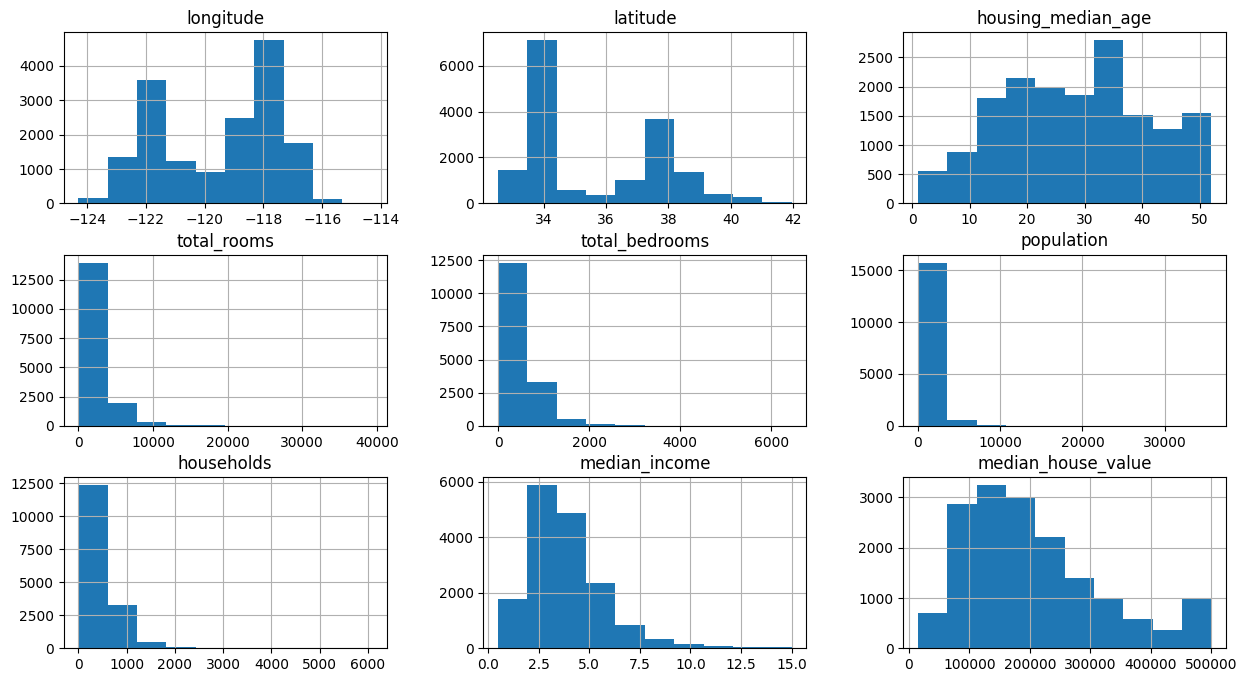

In [16]:
train_data.hist(figsize=(15 , 8))

<Axes: >

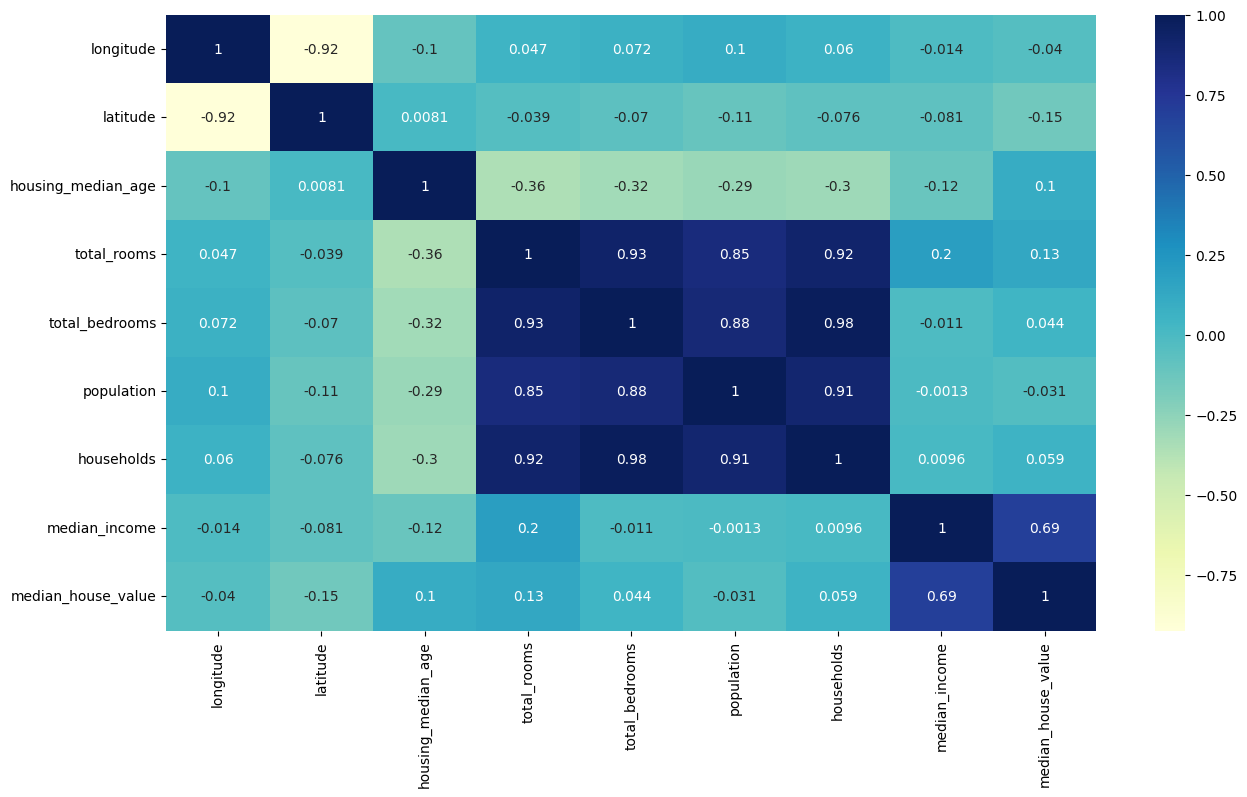

In [17]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True , cmap="YlGnBu")


In [18]:
train_data['total_rooms'] = np.log(train_data['total_rooms']+1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms']+1)
train_data['population'] = np.log(train_data['population']+1)
train_data['households'] = np.log(train_data['households']+1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

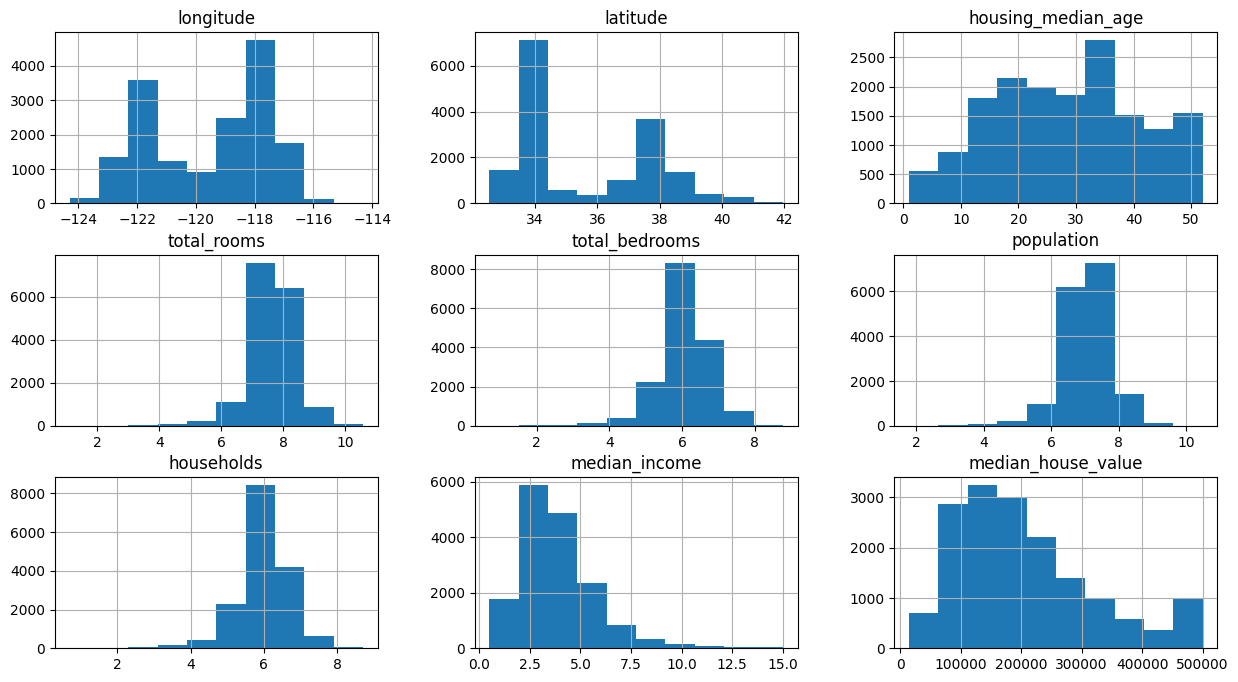

In [19]:
train_data.hist(figsize=(15, 8))

In [21]:
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7231
INLAND        5174
NEAR OCEAN    2132
NEAR BAY      1805
ISLAND           4
Name: count, dtype: int64

In [24]:
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity , dtype=int)).drop(['ocean_proximity'], axis=1)

<Axes: >

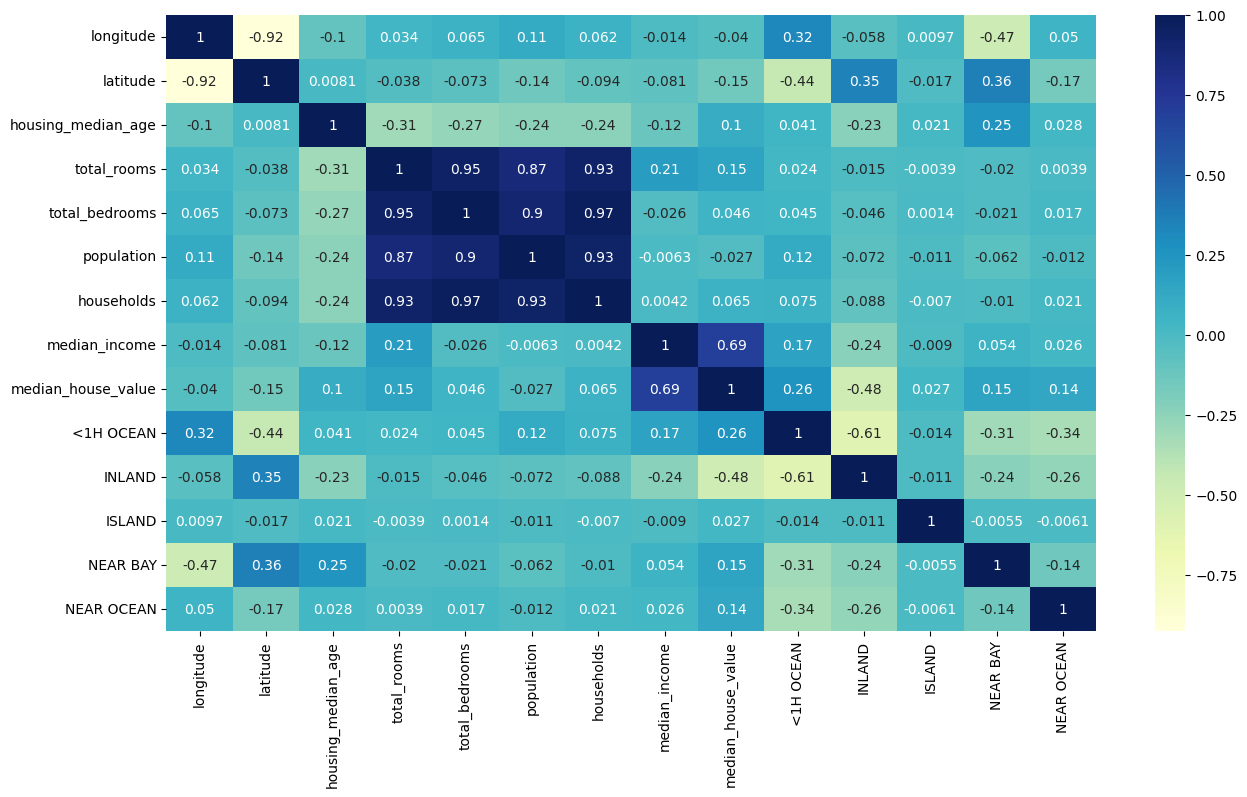

In [25]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(), annot=True , cmap="YlGnBu")


<Axes: xlabel='latitude', ylabel='longitude'>

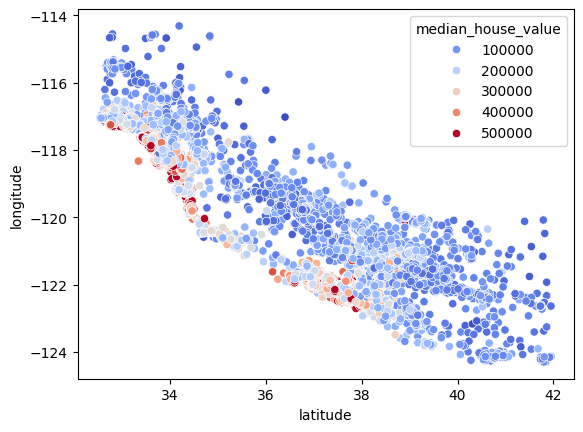

In [33]:
plt.Figure(figsize=(15, 8))
sns.scatterplot(x="latitude",y="longitude", data=train_data,hue="median_house_value", palette="coolwarm")